# Auditing a care-management risk score

## Section 2 — Understand the data

**Work individually.** The public file is synthetic: it preserves useful
patterns for replication but contains no original patient records.


## START/RESTART HERE

Before Task 1, run every setup code cell (cells with the
`# RUN THIS CELL FIRST` label) below in order.


In [1]:
# RUN THIS CELL FIRST
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
RACE_STYLES = {
    "black": {"color": "#6A3D9A", "linestyle": "--", "marker": "o"},
    "white": {"color": "#E69F00", "linestyle": "-", "marker": "s"},
}


In [2]:
# RUN THIS CELL FIRST
DATA_COMMIT = "daceb25bba00e65d7b05882f049e229a8bedb60c"
DATA_URL = (
    "https://gitlab.com/labsysmed/dissecting-bias/-/raw/"
    f"{DATA_COMMIT}/data/data_new.csv"
)
LOCAL_DATA_PATH = Path("data_new.csv")


def load_data(required_columns):
    """Load the course data from a local copy or the pinned public URL."""
    source = LOCAL_DATA_PATH if LOCAL_DATA_PATH.is_file() else DATA_URL
    data = pd.read_csv(source)

    missing_columns = sorted(set(required_columns) - set(data.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    return data


In [3]:
# RUN THIS CELL FIRST
section_2_columns = [
    "risk_score_t",
    "cost_t",
    "gagne_sum_t",
    "race",
]
df = load_data(section_2_columns)


## Naming convention and important variables

### Naming convention

- variables ending in `_tm1` were measured in the prior year;
- variables ending in `_t` were measured in year t, when the score,
  care-management decision, or outcome is observed;
- variables starting with `dem_` are demographic fields;
- names such as `cost_emergency_tm1` record prior-year cost by care setting or
  service;
- names ending in `_elixhauser_tm1` or `_romano_tm1` are prior-year
  diagnosis-based condition indicators; and
- names ending in `_tests_tm1` count prior-year laboratory tests.

### Important variables

- `cost_t` is total medical cost in year t;
- `gagne_sum_t` is the number of active chronic conditions in year t;
- `risk_score_t` is the existing commercial score used under the current
  policy; and
- `race` denotes whether a patient self-reported as Black or White.

An *active chronic condition* is a condition recorded as present in the current
year. Here, `gagne_sum_t` is a count-based proxy for illness burden, not a
complete measure of health or treatment benefit.


## Task 1 — Inspect the data

First, check the number of observations and the number of variables in the
dataset `df`.


In [4]:
df.shape


(48784, 160)

Next, select `section_2_columns` and run `.head()` to inspect the first five
rows of the variables used in this section.


In [5]:
df[section_2_columns].head()


,risk_score_t,cost_t,gagne_sum_t,race
0,1.987430,1200.0,0,white
1,7.677934,2600.0,3,white
2,0.407678,500.0,0,white
3,0.798369,1300.0,0,white
4,17.513165,1100.0,1,white


Compute the summary statistics of `gagne_sum_t`. What are the mean and median?
What is the standard deviation? What are the minimum and maximum?


In [6]:
df["gagne_sum_t"].agg(["mean", "median", "std", "min", "max"])


mean       1.354481
median     1.000000
std        1.942488
min        0.000000
max       17.000000
Name: gagne_sum_t, dtype: float64

Plot the distribution of `gagne_sum_t` as a histogram.


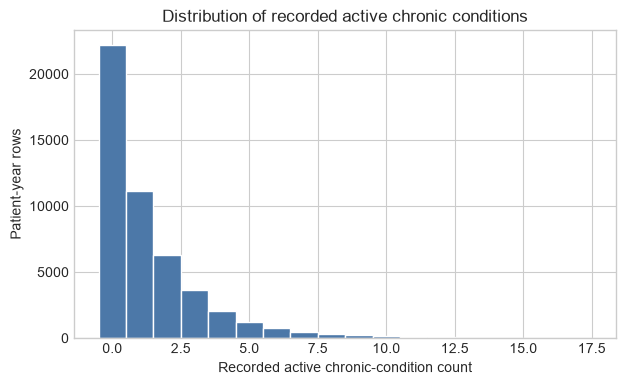

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(
    df["gagne_sum_t"].min() - 0.5,
    df["gagne_sum_t"].max() + 1.5,
    1,
)
ax.hist(
    df["gagne_sum_t"],
    bins=bins,
    color="#4C78A8",
    edgecolor="white",
)
ax.set(
    xlabel="Recorded active chronic-condition count",
    ylabel="Patient-year rows",
    title="Distribution of recorded active chronic conditions",
)
plt.show()


Compute the correlations among `gagne_sum_t`, `cost_t`, and `risk_score_t`.
Are the correlations positive or negative?


In [8]:
df[["gagne_sum_t", "cost_t", "risk_score_t"]].corr().round(3)


,gagne_sum_t,cost_t,risk_score_t
gagne_sum_t,1.000,0.355,0.570
cost_t,0.355,1.000,0.453
risk_score_t,0.570,0.453,1.000


## Task 2 — Look at the data by race

Report both the number and fraction of observations for each race.


In [9]:
race_counts = df["race"].value_counts()
race_summary = pd.DataFrame(
    {
        "observations": race_counts,
        "fraction": race_counts / len(df),
    }
)
race_summary


,observations,fraction
race,,
white,43202,0.885577
black,5582,0.114423


Compare the mean of `gagne_sum_t` by race.


In [10]:
df.groupby("race")["gagne_sum_t"].mean()


race
black    2.055536
white    1.263900
Name: gagne_sum_t, dtype: float64

Plot the distribution of `gagne_sum_t` by race.


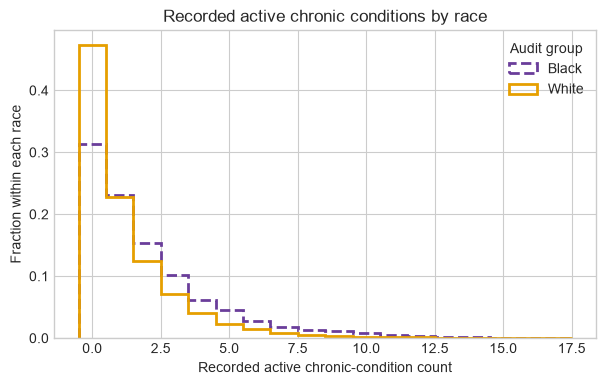

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(
    df["gagne_sum_t"].min() - 0.5,
    df["gagne_sum_t"].max() + 1.5,
    1,
)

for race, style in RACE_STYLES.items():
    values = df.loc[df["race"] == race, "gagne_sum_t"]
    ax.hist(
        values,
        bins=bins,
        weights=np.repeat(1 / len(values), len(values)),
        histtype="step",
        linewidth=2,
        label=race.title(),
        color=style["color"],
        linestyle=style["linestyle"],
    )

ax.set(
    xlabel="Recorded active chronic-condition count",
    ylabel="Fraction within each race",
    title="Recorded active chronic conditions by race",
)
ax.legend(title="Audit group")
plt.show()


## Task 3 — Identify candidate prediction features

From `df`, create a new dataset named `df_features` that contains only the
candidate prediction features:

1. Get the list of columns in `df`.
2. Create `feature_columns` by keeping columns that either end in `_tm1` or
   start with `dem_`; exclude any demographic column whose name contains
   `race`.
3. Use `feature_columns` to create `df_features`.


In [12]:
all_columns = df.columns.tolist()

feature_columns = [
    column
    for column in all_columns
    if (
        (column.endswith("_tm1"))
        or (column.startswith("dem_") and "race" not in column)
    )
]

df_features = df.loc[:, feature_columns].copy()
df_features.head()


,dem_female,dem_age_band_18-24_tm1,dem_age_band_25-34_tm1,dem_age_band_35-44_tm1,dem_age_band_45-54_tm1,dem_age_band_55-64_tm1,dem_age_band_65-74_tm1,dem_age_band_75+_tm1,alcohol_elixhauser_tm1,anemia_elixhauser_tm1,...,trig_min-low_tm1,trig_min-high_tm1,trig_min-normal_tm1,trig_mean-low_tm1,trig_mean-high_tm1,trig_mean-normal_tm1,trig_max-low_tm1,trig_max-high_tm1,trig_max-normal_tm1,gagne_sum_tm1
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,1,4
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Check the number of features in `df_features`.


In [13]:
df_features.shape[1]


149

Check that none of the four audit variables in `section_2_columns` entered the
candidate feature list.

Hint: use a set intersection; an empty set means no overlap.


In [14]:
set(section_2_columns) & set(feature_columns)


set()

## END-OF-SECTION CHECKPOINT — worked answer

The file has 48,784 patient-year observations and 160 variables;
`gagne_sum_t` is right-skewed (mean 1.354, median 1, standard deviation 1.942,
range 0–17), and all three pairwise correlations are positive:
`gagne_sum_t`–`cost_t` is 0.355, `gagne_sum_t`–`risk_score_t` is 0.570, and
`cost_t`–`risk_score_t` is 0.453.

White observations comprise 43,202 rows (88.56%) and Black observations 5,582
(11.44%). Mean `gagne_sum_t` is higher among Black rows (2.056 versus 1.264),
consistent with the race-specific histograms.

The 149 candidate predictors in `df_features` are prior-year `_tm1` columns
plus approved `dem_` columns excluding race. `cost_t` and `gagne_sum_t` are
later outcomes, `risk_score_t` is the existing score, and `race` is reserved
for auditing. None of the four audit variables appears in `df_features`.
